# Predecting the Restaurant Revenue Using Machine Learning Model's

This notebook will introduce some machine learning and data science concepts by exploring the problem of Revenue prediction.

The Step's Were going to take:
- **`Exploratory data analysis (EDA)`** - the process of going through a dataset and finding out more about it.
- **`Model training`** - create model(s) to learn to predict a target variable based on other variables.
- **`Model evaluation`** - evaluating a models predictions using problem-specific evaluation metrics.
- **`Model comparison`** - comparing several different models to find the best one.

## ``Problem Statement``

### Create a machine learning model to predict revenue of the restaurant based on the features present in the dataset.

#### **Dataset Attributes**

1. **`ID           `**          - Restaurant ID
2. **`Name         `**        - Nameof the Restaurant
3. **`Franchise    `**   - Restaurant has `franchise or not`
4. **`Category     `**    - specific type of category provided by restaurant
5. **`No_of_item   `**  - Different types of items provided by restaurant
6. **`Order_Placed `**- Order placed by customer to restaurant (in lacs)
7. **`Revenue      `**     - Total amount of income generated by the restaurant

**Import Required libraries**

In [1]:
# Regular EDA and Plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We want our plots to appear in the notebook
%matplotlib inline

# ignore the warnings
import warnings 
warnings.filterwarnings('ignore')

**Load Dataset**

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\revenue_prediction.csv") # Loading the dataset
df

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...,...,...
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689


**Data Inspection**

In [5]:
df.size # total values in dataset

800

In [6]:
df.shape  # (row's and column's)

(100, 8)

In [7]:
df.dtypes # checking the data types

Id                int64
Name             object
Franchise        object
Category         object
City             object
No_Of_Item        int64
Order_Placed    float64
Revenue           int64
dtype: object

**Exploration ( Exploratory Data Analysis or EDA )**

In [8]:
# Let's check the first 5 rows of our dataset

df.head() 

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715


In [9]:
df.sample(10) # checking random data

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
34,135,Jack's,No,Varied Menu,Pune,48,4.0,4100886
75,176,WhichWich,No,Bakery Cafe,Bengaluru,126,13.0,16549064
90,191,FarmerBoys,No,Family Style,Bengaluru,40,3.3,3426169
41,142,PizzaRanch,No,Frozen Desserts,Pune,51,4.4,4554237
44,145,PeiWeiAsianDiner,Yes,Steak,Bengaluru,48,4.0,4264176
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
52,153,PretAManger,Yes,Family Style,Noida,27,1.6,1763231
33,134,CaribouCoffee,No,Bakery Cafe,Gurugram,29,2.2,2371202
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
10,111,TacoJohn's,No,Frozen Desserts,Bengaluru,40,3.6,3945135


In [10]:
df.tail() # similarly checking last 5 rows

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689
99,200,Mimi'sBistro&Bakery,No,BBQ,Mumbai,50,4.4,4567678


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            100 non-null    int64  
 1   Name          100 non-null    object 
 2   Franchise     100 non-null    object 
 3   Category      100 non-null    object 
 4   City          100 non-null    object 
 5   No_Of_Item    100 non-null    int64  
 6   Order_Placed  100 non-null    float64
 7   Revenue       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [12]:
df['Revenue'].describe() # Statistical Analysis on Revenue col

count    1.000000e+02
mean     4.395161e+06
std      2.659932e+06
min      8.498700e+05
25%      2.688328e+06
50%      3.911401e+06
75%      5.330084e+06
max      1.969694e+07
Name: Revenue, dtype: float64

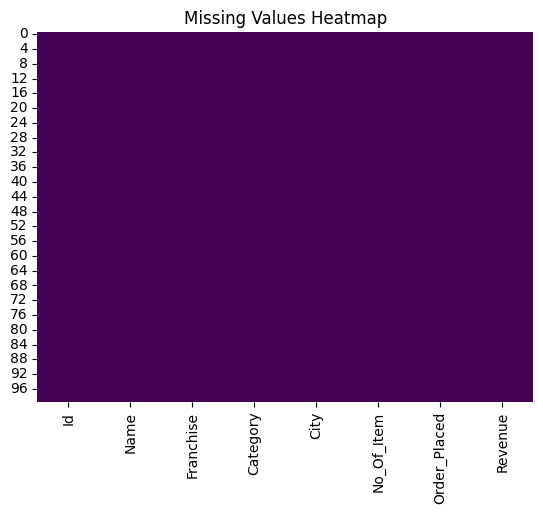

In [13]:
# Heatmap of missing values
sns.heatmap(df.isna(), cmap='viridis', cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


- Restaurant revenue dataset as zero null value's

In [14]:
# Let's see how many duplicated values are in our data frame

df.duplicated().sum() 

0

In [15]:
# changing the column (Order_Placed ) to ( Rating )

df.rename(columns = {'Order_Placed':'Rating'}, inplace = True)

**Feature Elimination**

- After analyzing the dataset, I observed that *``Revenue depends``* on the *``Rating column.``*

- When the *``rating increases``*, the *``revenue also tends to increase.``*

- This shows there is a relationship between rating and revenue.

- So, I selected Rating as the independent variable (input).

- I selected Revenue as the dependent variable (output).

- I removed all other columns using feature elimination.

- This helps to make the model simple and easy to understand.

- The model is trained only using rating to predict revenue.

In [16]:
# let's see is there any column name required to change

df.columns

Index(['Id', 'Name', 'Franchise', 'Category', 'City', 'No_Of_Item', 'Rating',
       'Revenue'],
      dtype='object')

As we observed that revenue column is depended on rating column because based on rating revenue is generated and 
customer start perfering only best rating product's or category's

In [17]:
#  let's drop not useful col's

df = df.drop(['Id', 'Name', 'Franchise', 'Category', 'City', 'No_Of_Item'], axis = 1)  
df.head()

,Rating,Revenue
0,5.5,5953753
1,6.8,7223131
2,1.9,2555379
3,2.5,2175511
4,4.2,4816715


**Realtion between Rating and Revenue col**

**Bi-Variant Analysis**

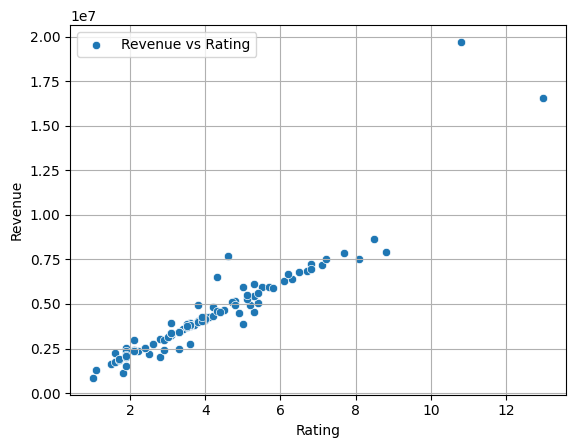

In [18]:
sns.scatterplot(data=df, x='Rating', y='Revenue')
plt.grid(True)
plt.legend(['Revenue vs Rating'])
plt.show()


Let's see relation beween Rating and Revenue by ploting two diiferent way's

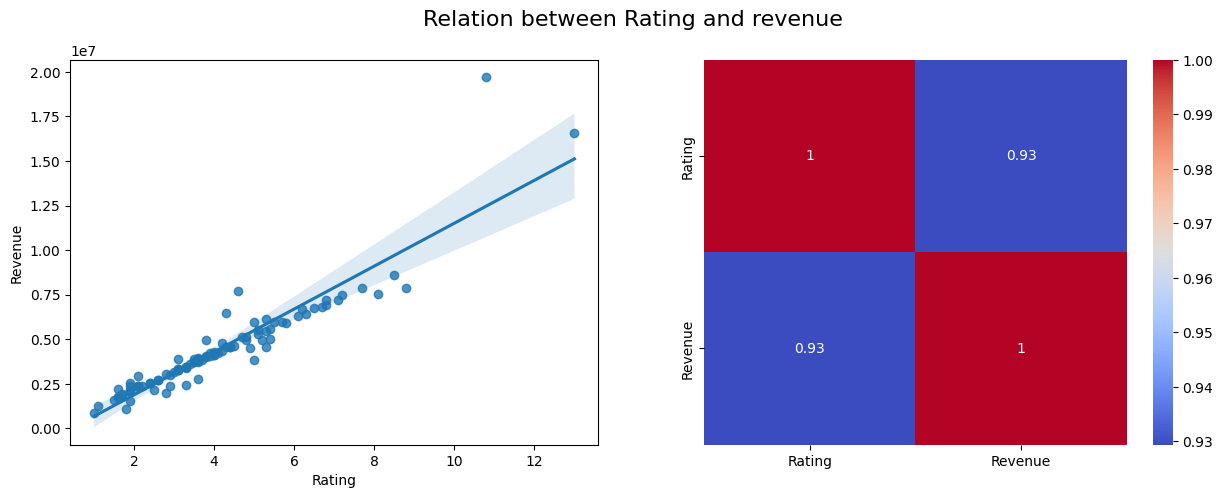

In [19]:
fig, axes = plt.subplots(1,2, figsize = (15,5))

# scatter + regression plot
sns.regplot(x="Rating", y="Revenue", data=df, ax = axes[0])

# correlation heatmap
corr = df[["Rating","Revenue"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm",ax = axes[1])

# suptitle for bith figure's
fig.suptitle('Relation between Rating and revenue', fontsize = 16 )
plt.show()

**insight**
- Data is in upward trend (most data is increased order)
- Revenue is strongly correlated with Rating.
- when ``Rating increases`` then ``Revenue also increases``
- similarly ``Rating decreases`` then ``Revenue also decreases``
- that means revenue is depended on customer rating's

**Create independent and dependent feature's**

In [20]:
# x = df.iloc[:,:-1].values
# y = df.iloc[:,-1].values

x = df.drop('Revenue', axis = 1)
y = df['Revenue']

**Model Building**

***Simple Linear Regression***

Let's divide the data into independent and dependent train test's

Actually here we are giving question and answer's to model by splitting the data

In [21]:
from sklearn.model_selection import train_test_split  # data splitting into training and testing

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 3300)

Let's start with `**``baseline model's``**

- `Linear Regression`
- `Decision Tree Regressor`
- `Random Forest Regressor`

why we are using this model's?

- here our dataset target column(dependent) contains numeric continues values 
- however regression model's are used slove numeric(target) problem's

**Training the simple Linear Regression on Training set**

In [22]:
from sklearn.linear_model import LinearRegression

Lr = LinearRegression()

here were training the independent and dependent col's

In [42]:
# Training the data

Lr.fit(x_train, y_train);


**Predicting the Testing set result's**

In [24]:
# Testing the data

y_pred_lr = Lr.predict(x_test)
y_pred_lr

array([7099716.8580781 , 8990048.76583359, 3823141.55130193,
        672588.37170945, 1302699.00762795, 1932809.64354644,
       9998225.78330318, 1554743.26199535, 3823141.55130193,
       1932809.64354644, 6217561.96779221, 3067008.78819973,
       7855849.6211803 , 7855849.6211803 , 6469606.22215961,
       5713473.45905741, 3823141.55130193, 2310876.02509754,
       5965517.71342481, 2814964.53383234])

We plot the predicted taining data by using the trained data

How actually model predicting the training data?

Does it peform accuratly or not?

Let's see by Visualising the plot

**Visualising the Training set results**

Text(0, 0.5, 'Revenue')

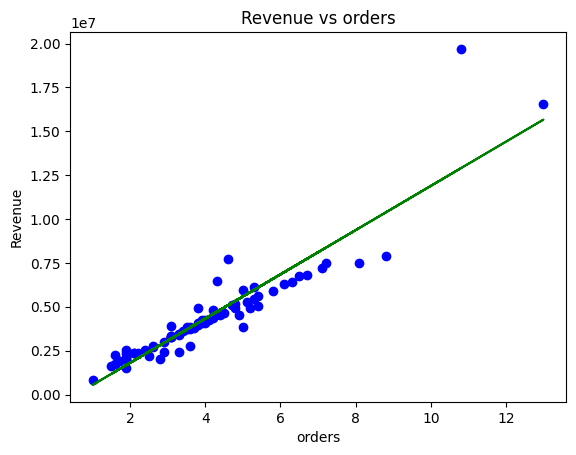

In [25]:
plt.scatter(x_train,y_train,color="blue")
plt.plot(x_train,Lr.predict(x_train),color="green")
plt.title("Revenue vs orders")
plt.xlabel("orders")
plt.ylabel("Revenue")


Similarly checking on Predicted test data by using a test data

**Visualising the Test set results**

Text(0, 0.5, 'Revenue')

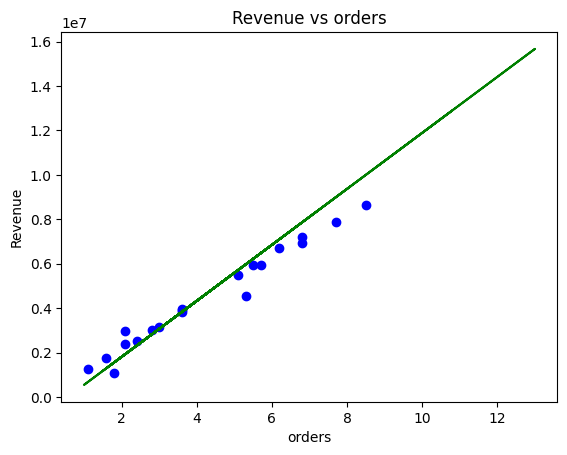

In [26]:
plt.scatter(x_test,y_test,color="blue")
plt.plot(x_train,Lr.predict(x_train),color="green")
plt.title("Revenue vs orders")
plt.xlabel("orders")
plt.ylabel("Revenue")

- Linear Regression model predicts the data(revenue values).
- Let's visualise the predicted data of revenue values.

**Model Predicted visualization**

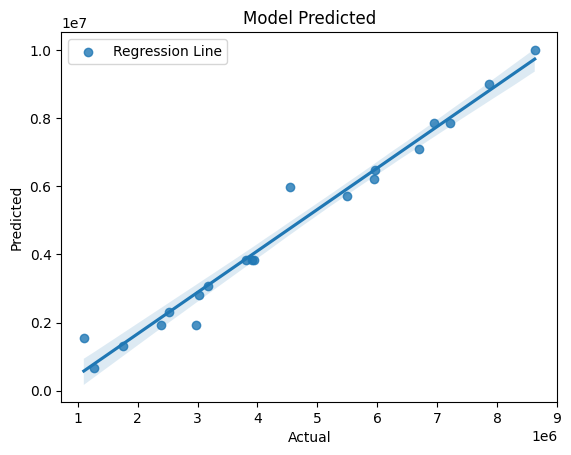

In [27]:
sns.regplot(x = y_test, y = y_pred_lr )  #
plt.title('Model Predicted')
plt.legend(['Regression Line'])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

**Model Evaluation**

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", (r2)*100)


MAE: 529453.0354571511
MSE: 454876519571.18585
RMSE: 674445.3421673145
R² Score: 90.63340374358008


Let's see how much our model correct or wronge

In [29]:
print("Average Revenue:", y_pred_lr.mean())
print("RMSE %:", (rmse / y_pred_lr.mean()) * 100) # our model rmse is 11% which good error predict prediction 
                                                  # if rmse is greater than 30% error our model is poor 

Average Revenue: 4661188.697073527
RMSE %: 14.469385086056635


our model predicted the `r2_score is 90%` which means it is a good score.

***Decision Tree Regression***

Let's see decision tree `how r2_score` gain?

In [41]:
from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor()

DTR.fit(x_train, y_train);


In [31]:
y_pred_dtr = DTR.predict(x_test)
y_pred_dtr

array([6313221.        , 7513524.        , 3456075.66666667,
        849870.        , 1998932.5       , 2354583.5       ,
       7904084.        , 1893486.5       , 3456075.66666667,
       2354583.5       , 5310501.        , 2706314.        ,
       6836483.        , 6836483.        , 5906596.        ,
       5286212.        , 3456075.66666667, 2551252.        ,
       5798488.        , 1999068.        ])

In [32]:

mae = mean_absolute_error(y_test, y_pred_dtr)
mse = mean_squared_error(y_test, y_pred_dtr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dtr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", (r2)*100)



MAE: 451591.4
MSE: 303585876336.1667
RMSE: 550986.2759962054
R² Score: 93.74870715359644


Similarly we check for decision tree also

In [33]:
print("Average Revenue:", y_pred_dtr.mean())
print("RMSE %:", (rmse / y_pred_dtr.mean()) * 100) 

Average Revenue: 4239095.45
RMSE %: 12.99773224016943


- here decision `r2_score is increased 3% `comparing to linear regressor
- rmse is also in good position which means model is good predictor

***Random Forest Regressor***

Let's see similarly for Random Forest Regressor

In [44]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor()

RFR.fit(x_train, y_train); # Training data

In [35]:
y_pred_rfr = RFR.predict(x_test) # Testing data
y_pred_rfr

array([6348097.03      , 7452352.81      , 3448639.54614286,
       1201579.082     , 1969417.29316667, 2350777.05661111,
       7709262.1       , 1922719.67338312, 3448639.54614286,
       2350777.05661111, 5360729.14238095, 2867139.54671032,
       6913205.32      , 6913205.32      , 5648739.33571429,
       5125788.50053571, 3448639.54614286, 2487093.99433333,
       5741311.648     , 2284835.38166667])

In [36]:

mae = mean_absolute_error(y_test, y_pred_rfr)
mse = mean_squared_error(y_test, y_pred_rfr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rfr)  # Testing the R2_score

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", (r2)*100)


MAE: 432705.86497788597
MSE: 279932303726.10175
RMSE: 529086.2913798672
R² Score: 94.23577002698734


In [37]:
# similarly checking for Random forest regressor

print("Average Revenue:", y_pred_rfr.mean())
print("RMSE %:", (rmse / y_pred_rfr.mean()) * 100) 

Average Revenue: 4249647.446477092
RMSE %: 12.45012199349557


- Random Forest Regressor performed very well `r_score which is 94%` comparing to linear and decision tree.
- RMSE is performed similar to decision tree

Here we compare the all 3 baseline models R2_score. to see which model give's it's best 

**Compare basic model R2_score**

In [38]:

def compare_r2Score(y_test, 
                    y_pred_lr, 
                    y_pred_dtr=None,
                    y_pred_rfr=None):
    
    scores = {}

    scores["Linear Regression"] = r2_score(y_test, y_pred_lr) * 100
        
    if y_pred_dtr is not None:
        scores["Decision Tree"] = r2_score(y_test, y_pred_dtr) * 100
        
    if y_pred_rfr is not None:
        scores["Random Forest"] = r2_score(y_test, y_pred_rfr) * 100

    return scores

In [39]:
model_score = compare_r2Score(y_test,
                              y_pred_lr,
                              y_pred_dtr,
                              y_pred_rfr)
model_score

{'Linear Regression': 90.63340374358008,
 'Decision Tree': 93.74870715359644,
 'Random Forest': 94.23577002698734}

Let's understand by visualising the plot on model's R2_score's

**model's R2_score Visualise**

<Axes: >

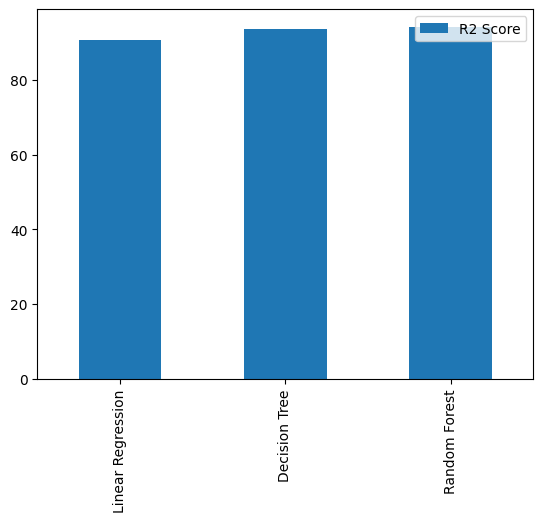

In [40]:

model_compare = pd.DataFrame(model_score, index=['R2 Score'])
model_compare.T.plot.bar()

Here clearly understanded by visualising plot. the random forest regressor as given best r2_score comparing to linear, decision tree regressor's

**Conclusion**

- Implemented multiple regression algorithms to model and predict revenue.

- Baseline models achieved an initial **`R² score of 0.90 and prediction error RMSE achevied around 12%`**.

- The Random Forest Regressor outperformed all other models.

- Achieved performance improvement from **`r2_score = 0.90 to R² = 0.94`**.

- Results suggest the presence of *``non-linear relationships``*, which ensemble tree-based models effectively capture.